In [13]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Getting NIST data

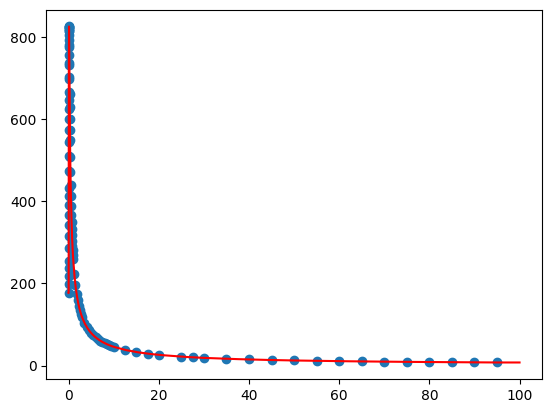

In [14]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

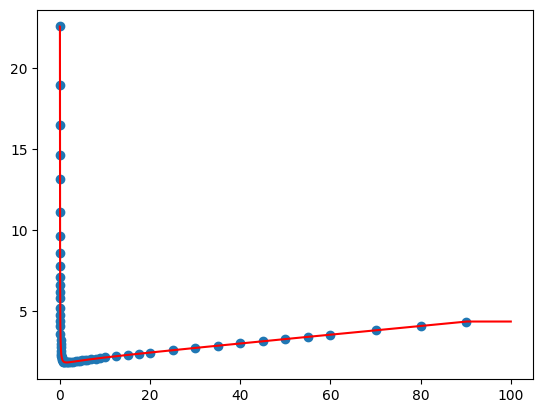

In [15]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# Reading in each particle phsp to calculate LET

In [16]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        particle_data['Dose_weights'] = particle_data['Weight']*particle_data['LET']
        particle_data['Dose_weights'] = particle_data['Dose_weights']/particle_data['Dose_weights'].sum()
        particle_data['LET_d'] = particle_data['Dose_weights']*particle_data['LET']

        LET = round(particle_data['LET_d'].sum(),2)
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        LET = 0

    print(phsp_path + ' finished')

    return LET

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_20808\162186939.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [17]:
dir = r"..\TOPAS_data\do_9spots_phase"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'LET'])
for file in list:
    if os.path.splitext(file)[-1] == '.phsp':
        newrow = {}
        newrow['Depth'] = float(os.path.splitext(file)[0])
        newrow['LET'] = Calculate_LET_from_phsp(os.path.join(dir,file), Expanded_SP, Expanded_SP_el)

        newrow = pd.DataFrame([newrow])
        topas_let = pd.concat([topas_let, newrow], ignore_index=True)

topas_let = topas_let.sort_values(by='Depth')
print(topas_let)

..\TOPAS_data\do_9spots_phase\0.phsp finished


C:\Users\linux\AppData\Local\Temp\ipykernel_20808\3365790931.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


..\TOPAS_data\do_9spots_phase\10.phsp finished
..\TOPAS_data\do_9spots_phase\20.phsp finished
..\TOPAS_data\do_9spots_phase\30.phsp finished
..\TOPAS_data\do_9spots_phase\32.phsp finished
..\TOPAS_data\do_9spots_phase\33.phsp finished
..\TOPAS_data\do_9spots_phase\34.phsp finished
..\TOPAS_data\do_9spots_phase\35.5.phsp finished
..\TOPAS_data\do_9spots_phase\35.phsp finished
..\TOPAS_data\do_9spots_phase\36.5.phsp finished
..\TOPAS_data\do_9spots_phase\36.phsp finished
..\TOPAS_data\do_9spots_phase\37.5.phsp finished
..\TOPAS_data\do_9spots_phase\37.phsp finished
..\TOPAS_data\do_9spots_phase\38.5.phsp finished
..\TOPAS_data\do_9spots_phase\38.phsp finished
..\TOPAS_data\do_9spots_phase\39.5.phsp finished
..\TOPAS_data\do_9spots_phase\39.phsp finished
..\TOPAS_data\do_9spots_phase\40.5.phsp finished
..\TOPAS_data\do_9spots_phase\40.phsp finished
..\TOPAS_data\do_9spots_phase\41.5.phsp finished
..\TOPAS_data\do_9spots_phase\41.phsp finished
..\TOPAS_data\do_9spots_phase\42.5.phsp finish

Text(0.5, 1.0, 'LET as function of depth')

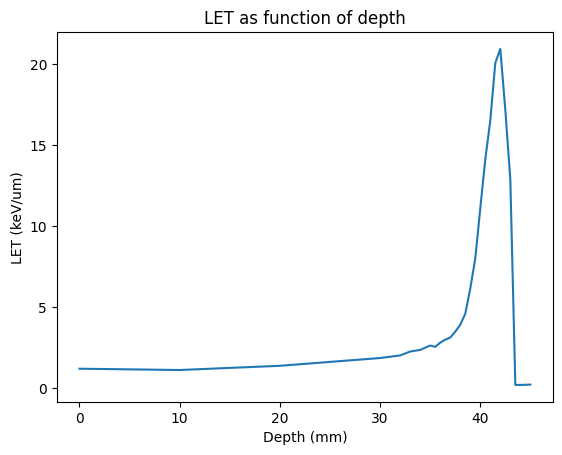

In [18]:
#plt.plot(topas_let['Depth'], topas_let['Mean LET'], label='mean LET')
plt.plot(topas_let['Depth'], topas_let['LET'])
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.title('LET as function of depth')

In [75]:
dir = r"..\TOPAS_data\NICE ONE\Dose"
list = os.listdir(dir)

topas_dose = pd.DataFrame(columns=['Depth', 'Dose'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Dose'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    newrow = pd.DataFrame([newrow])
    topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)

#normalise dose
topas_dose = topas_dose.sort_values(by='Depth')
topas_dose['Dose_norm'] = topas_dose['Dose']/max(topas_dose['Dose'])
topas_dose_nice = topas_dose

print(topas_dose)

    Depth          Dose  Dose_norm
0     0.0  2.341364e-05   0.211411
1    10.0  2.723561e-05   0.245921
2    20.0  3.217524e-05   0.290523
3    30.0  4.255743e-05   0.384269
4    32.0  4.789577e-05   0.432471
5    34.0  5.285815e-05   0.477278
7    36.0  6.419685e-05   0.579660
6    36.5  6.737528e-05   0.608359
9    37.0  7.206589e-05   0.650712
8    37.5  7.856488e-05   0.709395
13   38.0  8.586219e-05   0.775285
10   38.5  9.539271e-05   0.861340
11   38.6  9.754188e-05   0.880746
12   38.8  1.015364e-04   0.916814
19   39.0  1.060050e-04   0.957163
14   39.2  1.085492e-04   0.980136
15   39.4  1.100251e-04   0.993462
16   39.5  1.107492e-04   1.000000
17   39.6  1.106946e-04   0.999507
18   39.8  1.087307e-04   0.981774
23   40.0  1.062511e-04   0.959385
20   40.2  9.883385e-05   0.892411
21   40.4  9.190819e-05   0.829877
22   40.5  8.688437e-05   0.784515
25   41.0  6.028690e-05   0.544355
24   41.5  3.624144e-05   0.327239
27   42.0  1.743911e-05   0.157465
26   42.5  6.464053e

C:\Users\linux\AppData\Local\Temp\ipykernel_20808\3093518648.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)


In [97]:
dir = r"..\TOPAS_data\do_9spots\Dose"
list = os.listdir(dir)

topas_dose = pd.DataFrame(columns=['Depth', 'Dose'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Dose'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    newrow = pd.DataFrame([newrow])
    topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)

#normalise dose
topas_dose = topas_dose.sort_values(by='Depth')
topas_dose['Dose_norm'] = topas_dose['Dose']/max(topas_dose['Dose'])

C:\Users\linux\AppData\Local\Temp\ipykernel_20808\1478202894.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)


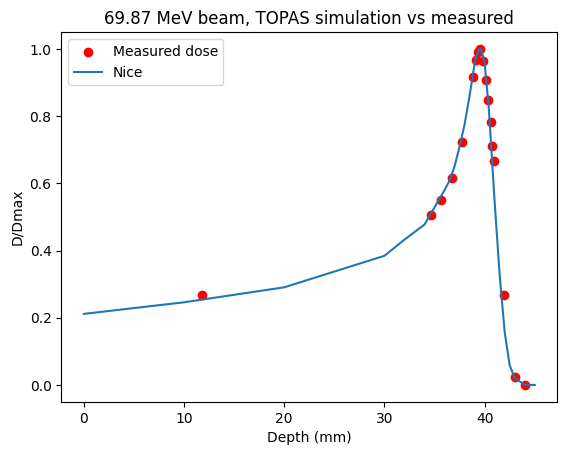

In [100]:
data = pd.read_excel(r"../Mid LET calculation/BP 69.87 measured - copy for scripts.xlsx")

BP_measured = pd.DataFrame()
BP_measured['Depth'] = data['Depth (mm)']
BP_measured['Dose'] = data['Dose (Gy)']/np.max(data['Dose (Gy)'])

plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
# plt.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label = 'TOPAS dose')
plt.plot(topas_dose_nice['Depth'], topas_dose_nice['Dose_norm'], label = 'Nice')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

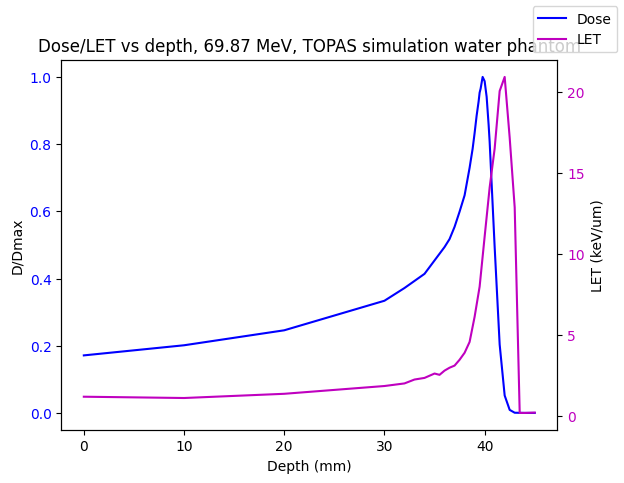

In [21]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('D/Dmax')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(topas_let['Depth'], topas_let['LET'], label='LET', color='m')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='m')

plt.title('Dose/LET vs depth, 69.87 MeV, TOPAS simulation water phantom')

fig.legend()

## TOPAS dose from phsp

KeyError: 'Dose'

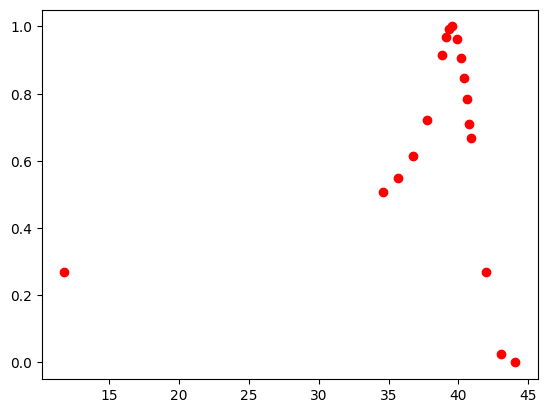

In [22]:
plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
plt.plot(topas_let['Depth'], topas_let['Dose']/max(topas_let['Dose']), label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()